# <div align='center'>🌍 Cidades Inteligentes: Qualidade do Ar em Bogotá (RMCAB) </div>

![Banner](https://raw.githubusercontent.com/JamaicaStoAndre/Ci-ncia-de-dados-com-Pandas/master/bogota_air_quality_banner.png)

---

## 🎓 Contexto: IA na Borda - Mestrado UFSC

Este material faz parte do projeto de monitoramento da **Rede de Monitoramento da Qualidade do Ar de Bogotá (RMCAB)**. Aqui, exploramos a **Biblioteca Pandas** como a ferramenta central da **Fase B (Design e Preparação)** da nossa arquitetura padronizada de Ciência de Dados.

---
### QR Code para acesso ao repositório

<div align="center">
  <img src="/content/drive/MyDrive/1-MestradoUFSC/IA_NA_BORDA/QRCode_Github.png" alt="QRCode" width="82" height="82">
</div>


## 🧪 Introdução ao Pandas: Estruturas de Dados

Antes de ler arquivos complexos, vamos entender a base: **Series** e **DataFrames**.

## Origem dos dados
- Dados extraídos da Rede de Monitoramento de Bogotá (RMCAB), com 166.441 registros de 21 estações durante o ano de 2021

## 📂 1. Leitura de Arquivos (CSV / Excel) - Topico do Trabalho

Agora escalamos para dados reais. O Pandas brilha na ingestão automática de grandes volumes (Big Data).

- Pandas suporta **CSV, Excel (.xlsx, .xls), JSON, Parquet e até ODS (OpenDocument)**.
    Nota: Para .ods ou .xlsx, pode ser necessário instalar bibliotecas como 'odfpy' ou 'openpyxl'.

## Dataset compartilhado no GoogleDrive
- Link do dataset:
https://drive.google.com/file/d/1Hf9RhmC2GJyunZoDYdEVVxeuzc-RT3zv/view?usp=sharing

In [ ]:
import pandas as pd           # Importa a biblioteca Pandas, usada para manipular tabelas (DataFrames)
import re                     # Importa a biblioteca 're' (Expressões Regulares) para buscar padrões em textos
import os                     # Importa a biblioteca 'os', que ajuda a interagir com o sistema operacional
import numpy as np            # Importa numpy para operações numéricas e tratamento de NaN
import folium                 # Importa folium para criar mapas interativos
from folium.plugins import HeatMap # Importa a função de mapa de calor do folium
import re                     # Importa re para limpeza de padrões em texto
import os

# --- 1. FUNÇÃO PARA CONVERTER COORDENADAS (DMS -> DECIMAL) ---
def parse_dms(coor):                                # Define a função que receberá o texto da coordenada
    if not isinstance(coor, str): return coor       # Verifica: se o dado não for um texto, retorna o valor original
    parts = re.split(r'[^\d\w\.]+', coor)           # Usa regex para dividir o texto em partes (graus, minutos, etc)
    try:                                            # Inicia um bloco de tentativa (caso algo dê erro no cálculo)
        degrees = float(parts[0])                   # Converte a primeira parte (graus) para número decimal
        minutes = float(parts[1])                   # Converte a segunda parte (minutos) para número decimal
        seconds = float(parts[2])                   # Converte a terceira parte (segundos) para número decimal
        direction = parts[3] if len(parts) > 3 else 'N' # Pega a letra da direção (N, S, E, O) ou assume 'N'
        dec_coord = degrees + minutes / 60 + seconds / 3600 # Aplica a fórmula matemática para converter para graus decimais
        if direction in ['S', 'W']:                 # Verifica se a direção é Sul (S) ou Oeste (W)
            dec_coord *= -1                         # Se for S ou W, torna o valor da coordenada negativo
        return dec_coord                            # Retorna o resultado final (o número pronto para o mapa)
    except:                                         # Caso ocorra qualquer erro no processo acima...
        return None                                 # ...retorna 'None' (vazio) para não travar o código

# --- 2. FUNÇÃO PARA PREPARAR O LINK DE DOWNLOAD ---
def carregar_via_link(gdrive_url):                  # Define a função que transforma o link de visualização em download
    match = re.search(r'/d/([a-zA-Z0-9_-]+)', gdrive_url) # Procura no link o ID único do arquivo no Google Drive
    if match:                                       # Se o ID for encontrado com sucesso...
        file_id = match.group(1)                    # ...extrai esse código identificador do arquivo
        return f'https://drive.google.com/uc?id={file_id}&export=download' # Retorna o link direto de download
    return gdrive_url                               # Se não encontrar, retorna o link original

# --- 3. EXECUÇÃO PRINCIPAL ---
url_compartilhada = "https://drive.google.com/file/d/1Hf9RhmC2GJyunZoDYdEVVxeuzc-RT3zv/view?usp=sharing" # Endereço do arquivo

try:                                                # Tenta executar o bloco de carregamento e manipulação
    csv_path = carregar_via_link(url_compartilhada) # Chama a função que prepara o link para download direto
    #
    #
    #____________Tema do trabalho
    # pd.read_excel(caminho)   # Lê arquivos do Microsoft Excel
    # pd.read_excel(caminho, engine='odf') # Lê arquivos de planilhas OpenDocument (LibreOffice)
    #d.read_json(caminho)    # Lê arquivos no formato JSON (comum na web)
    df = pd.read_csv(csv_path)                      # Tema Trabalho Equipe 5: Leitura de arquivo CSV(Ela lê o arquivo e o transforma em um DataFrame (uma tabela inteligente, tipo uma aba do Excel na memória do computador))

    df['Lat_Dec'] = df['Latitude'].apply(parse_dms) # Aplica a função de conversão em cada linha da coluna Latitude (Decimal)
    df['Lon_Dec'] = df['Longitude'].apply(parse_dms) # Aplica a função de conversão em cada linha da coluna Longitude(Decimal)

    print(f"✅ Sucesso! Dados carregados e convertidos.") # Imprime mensagem de sucesso no console
    display(df.head())                              # Exibe uma amostra com as 5 primeiras linhas da tabela
except Exception as e:                              # Caso ocorra qualquer erro (ex: link quebrado)...
    print(f"❌ Erro: {e}")                          # ...imprime a mensagem de erro detalhada

✅ Sucesso! Dados carregados e convertidos.


,DateTime,Station,PM2.5,PM10,CO,O3,Latitude,Longitude,Lat_Dec,Lon_Dec
0,2023-01-01 01:00:00,USM,12.5,25.0,0.8,0.02,"4°31'55.4""N","74°07'01.7""W",4.532056,-74.117139
1,2023-01-01 02:00:00,USM,14.2,28.5,0.9,0.01,"4°31'55.4""N","74°07'01.7""W",4.532056,-74.117139
2,2023-01-01 03:00:00,USM,18.7,35.2,1.1,0.01,"4°31'55.4""N","74°07'01.7""W",4.532056,-74.117139
3,2023-01-01 04:00:00,USM,22.1,42.0,1.3,0.00,"4°31'55.4""N","74°07'01.7""W",4.532056,-74.117139
4,2023-01-01 05:00:00,USM,55.4,85.0,2.1,0.00,"4°31'55.4""N","74°07'01.7""W",4.532056,-74.117139


## 📊 2. Tópico do Trabalho: Criação de Séries, DataFrame e Visualização do resultado
- Tópico do trabalho

In [ ]:
# 1. Criando uma Series (Uma coluna única de dados)
poluicao_pm25 = pd.Series([12.5, 45.3, 30.1, 55.4]) # Cria uma série com 4 valores flutuantes
print("Exemplo de Series (Níveis de PM2.5):")         # Título do output
print(poluicao_pm25)                                # Exibe a série na tela

# 2. Criando um DataFrame (Uma tabela de dados)
dados_simulados = {                                 # Define um dicionário com os dados
    'Estacao': ['Kennedy', 'Usme', 'Suba'],       # Coluna de texto (Categorias)
    'Nivel_PM10': [25.4, 18.2, 22.1],               # Coluna de números (Metadados)
    'Atividade': [True, True, False]               # Coluna booleana (Status)
}

df_exemplo = pd.DataFrame(dados_simulados)          # Converte o dicionário em um DataFrame real
print("\nExemplo de DataFrame de Sensores:")          # Título informativo
display(df_exemplo)                                 # Exibe a tabela organizada visualmente

Exemplo de Series (Níveis de PM2.5):
0    12.5
1    45.3
2    30.1
3    55.4
dtype: float64

Exemplo de DataFrame de Sensores:


,Estacao,Nivel_PM10,Atividade
0,Kennedy,25.4,True
1,Usme,18.2,True
2,Suba,22.1,False


## 3 - Operações básicas (filtros, agrupamentos, estatísticas)

In [ ]:
if 'df' in locals():
    # a) ESTATÍSTICAS: Resumo completo da saúde operacional dos sensores
    print("--- Estatísticas Operacionais (PM2.5, PM10) ---")
    display(df[['PM2.5', 'PM10']].describe()) #Describe: Gera automaticamente a média, desvio padrão, valores mínimos e máximos dos dados de poluição: count, mean, std, min, percentis e max

    # b) AGRUPAMENTOS (GroupBy): Descobrir a poluição média por bairro de Bogotá
    agrupado = df.groupby('Station')[['PM2.5', 'PM10']].mean() #Aqui, o código "junta" os dados por estação de monitoramento para calcular a média de poluição de cada localidade
    print("\n--- Média de Poluição por Estação --- ")
    display(agrupado.head())

    # c) FILTROS: Selecionar apenas horários onde o ar estava perigoso (PM2.5 > 35)
    critico = df[df['PM2.5'] > 35]                  # Isso seleciona apenas as linhas da tabela onde a qualidade do ar é considerada crítica.
    print(f"\n🔥 Identificamos {len(critico)} eventos críticos de poluição.")
    display(critico[['DateTime', 'Station', 'PM2.5']].head())

--- Estatísticas Operacionais (PM2.5, PM10) ---


,PM2.5,PM10
count,24.000000,24.000000
mean,32.016667,54.041667
std,19.740263,29.327164
min,10.200000,20.400000
25%,14.875000,28.475000
50%,23.900000,43.500000
75%,49.550000,77.050000
max,70.100000,115.400000



--- Média de Poluição por Estação --- 


,PM2.5,PM10
Station,,
KEN,56.616667,90.066667
TUN,27.350000,48.383333
USM,30.833333,52.366667
USQ,13.266667,25.350000



🔥 Identificamos 9 eventos críticos de poluição.


,DateTime,Station,PM2.5
4,2023-01-01 05:00:00,USM,55.4
5,2023-01-01 06:00:00,USM,62.1
6,2023-01-01 01:00:00,KEN,45.2
7,2023-01-01 02:00:00,KEN,48.7
8,2023-01-01 03:00:00,KEN,52.1


### 4 - NumPy e a "Mágica" dos Gráficos

Para que possamos ver os dados em forma de imagem, precisamos de um "motor matemático". O **NumPy** é esse motor. Ele transforma os dados do **Pandas** em formatos que as bibliotecas de desenho (como o **Matplotlib**) conseguem processar.

- 3 Visualizações Independentes:
- Linha: Tendência de dados.
- Barras: Comparação de categorias.
- Dispersão: Correlação entre variáveis.

Neste exemplo, vamos aprender como simular uma tendência de poluição. Note que:
- Usamos a função `np.arange` para criar uma linha do tempo.
- Usamos a função `np.random.randint` para dar realismo aos dados (simulando que o sensor oscila um pouco).
- Usamos o método `plt.plot` para transformar esses números em uma linha visual.

--- EXIBINDO GRÁFICO 1: LINHA ---


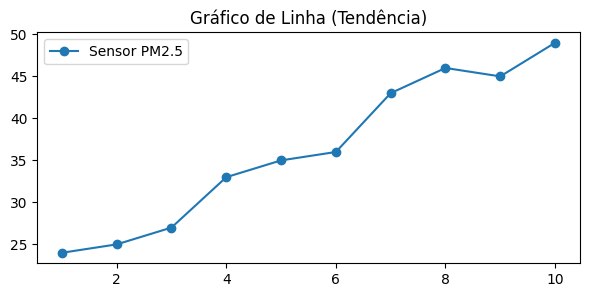


--- EXIBINDO GRÁFICO 2: BARRAS ---


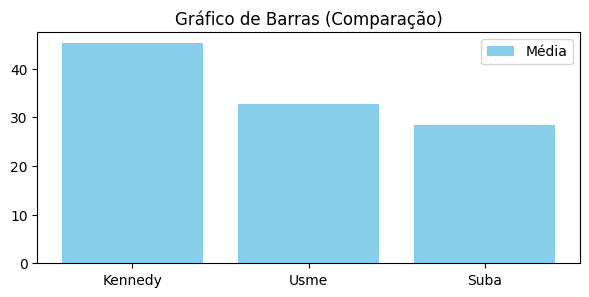


--- EXIBINDO GRÁFICO 3: DISPERSÃO ---


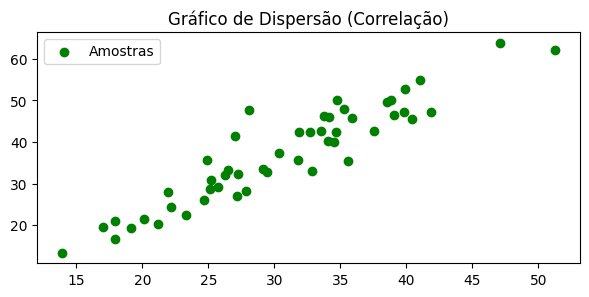

In [3]:
import numpy as np                                          # NumPy: Biblioteca para cálculos matemáticos
import matplotlib.pyplot as plt                            # Matplotlib: Biblioteca para criar os desenhos

# --- 1. SELEÇÃO DO GRÁFICO DE LINHA ---
print("--- EXIBINDO GRÁFICO 1: LINHA ---")
dias = np.arange(1, 11)                                     # NumPy: Função arange cria sequência de 1 a 10
poluicao = 20 + (dias * 3) + np.random.randint(-2, 3, 10)   # NumPy: randint sorteia números aleatórios (ruído)

plt.figure(figsize=(7, 3))                                  # Matplotlib: Define o tamanho da figura (largura, altura)
plt.plot(dias, poluicao, marker='o', label='Sensor PM2.5')  # Matplotlib: MÉTODO .plot() ESCOLHE O TIPO LINHA
plt.title("Gráfico de Linha (Tendência)")                  # Matplotlib: Define o título do topo
plt.legend()                                                # Matplotlib: Exibe a LEGENDA no gráfico
plt.show()                                                  # Matplotlib: Finaliza e exibe o gráfico na tela

# --- 2. SELEÇÃO DO GRÁFICO DE BARRAS ---
print("\n--- EXIBINDO GRÁFICO 2: BARRAS ---")
estacoes = ['Kennedy', 'Usme', 'Suba']                      # Python: Lista com nomes das categorias
medias = np.array([45.2, 32.8, 28.5])                       # NumPy: array converte lista para formato numérico

plt.figure(figsize=(7, 3))                                  # Matplotlib: Define o tamanho da figura
plt.bar(estacoes, medias, color='skyblue', label='Média')   # Matplotlib: MÉTODO .bar() ESCOLHE O TIPO BARRAS
plt.title("Gráfico de Barras (Comparação)")                # Matplotlib: Define o título
plt.legend()                                                # Matplotlib: Exibe a LEGENDA
plt.show()                                                  # Matplotlib: Exibe o gráfico

# --- 3. SELEÇÃO DO GRÁFICO DE DISPERSÃO ---
print("\n--- EXIBINDO GRÁFICO 3: DISPERSÃO ---")
pm25 = np.random.normal(30, 10, 50)                         # NumPy: normal gera 50 pontos com média 30
pm10 = pm25 * 1.2 + np.random.normal(0, 5, 50)              # NumPy: Cria relação matemática entre as variáveis

plt.figure(figsize=(7, 3))                                  # Matplotlib: Define o tamanho da figura
plt.scatter(pm25, pm10, color='green', label='Amostras')    # Matplotlib: MÉTODO .scatter() ESCOLHE O TIPO PONTOS
plt.title("Gráfico de Dispersão (Correlação)")             # Matplotlib: Define o título
plt.legend()                                                # Matplotlib: Exibe a LEGENDA
plt.show()                                                  # Matplotlib: Exibe o gráfico final

## 🗺️ 5. Resultado Final: Visualização de Dados Geospaciais
- Mapa de Calor (Prototipando IA na Borda)

In [ ]:
if 'df' in locals():
    m = folium.Map(location=[4.65, -74.1], zoom_start=12, tiles='cartodbpositron') # Cria mapa base
    calor = [[r['Lat_Dec'], r['Lon_Dec'], r['PM2.5']] for i, r in df.iterrows()] # Lista Latitude/Longitude/PM2.5. Aqui acontece a Extração de Dados. O código percorre as linhas do seu DataFrame (df.iterrows()) e pega a Latitude, Longitude e o nível de poluição para criar uma lista de pontos.
    HeatMap(calor, radius=18).add_to(m)                   # "Mapa de Calor", onde as áreas com maior concentração de poluição ficam com cores mais intensas (geralmente vermelho/amarelo).
    display(m)                                            # Exibe o mapa final de Bogotá

---

## 6 - Desafio Prático & Resolução

**Mãos à obra:**
1. Filtre apenas a estação **'KEN'** (Kennedy) e exiba a média de PM2.5 dela.
2. Crie uma nova coluna chamada **'PM_Soma'** que seja a soma de PM2.5 + PM10.

In [2]:
if 'df' in locals():
    # 1. Filtro local e média
    media_kennedy = df[df['Station'] == 'KEN']['PM2.5'].mean() # Filtra Kennedy e extrai média
    print(f"📊 Média PM2.5 em Kennedy: {media_kennedy:.2f}")

    # 2. Manipulação: Criando nova coluna via soma de colunas existentes
    df['PM_Soma'] = df['PM2.5'] + df['PM10']        # Operação aritmética entre vetores de dados
    print("🆕 Nova coluna 'PM_Soma' criada com sucesso!")
    display(df[['Station', 'PM2.5', 'PM10', 'PM_Soma']].head())